# Client Churn Prediction — SaaS Client Data

**Goal:** Build a predictive model to identify corporate clients who are likely to churn, so the business can intervene proactively (e.g. via customer success outreach, discounts, or renewal campaigns).

This notebook covers:
1. Data preparation
2. Exploratory Data Analysis (EDA)
3. Target Variables
4. Feature Engineering
5. Train/test split strategy
6. Model selection & justification
7. Model training, tuning, and evaluation
8. Final Evaluation on test set
9. Quick Sanity Check
10. Final model recommendation and business trade-offs


In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    f1_score
)
from xgboost import XGBClassifier

# Reproducibility
RANDOM_STATE = 42

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', 50)


Matplotlib is building the font cache; this may take a moment.


## 2. Load Data & Initial Inspection

In [2]:
df = pd.read_csv('../data/data_file.csv')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Shape: 10000 rows, 19 columns


,Unnamed: 0,company_size,monthly_usage_hours,num_logins,num_support_tickets,account_age_months,num_products_used,has_custom_integration,region,industry,plan_type,base_price_usd,discount_rate,is_annual_contract,num_admin_users,days_since_last_login,email_open_rate,webinar_attendance_last_3mo,churned
0,0,864,14.173497,32,1,27,1,No,Europe,Education,Basic,1000,0.305100,Yes,6,1,0.969404,0,No
1,1,3056,8.799041,33,1,41,1,No,North America,Education,Basic,5000,0.359084,Yes,6,38,0.678786,0,No
2,2,5134,12.830030,39,2,7,3,No,Asia,Healthcare,Basic,500,0.375026,No,8,4,0.207863,1,No
3,3,2683,3.493881,16,0,43,4,Yes,North America,Telecom,Pro,1000,0.254083,No,2,30,0.719574,4,No
4,4,5279,6.639796,28,2,31,1,No,Asia,Education,Basic,500,0.323974,Yes,9,48,0.682488,2,Yes


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   10000 non-null  int64  
 1   company_size                 10000 non-null  int64  
 2   monthly_usage_hours          10000 non-null  float64
 3   num_logins                   10000 non-null  int64  
 4   num_support_tickets          10000 non-null  int64  
 5   account_age_months           10000 non-null  int64  
 6   num_products_used            10000 non-null  int64  
 7   has_custom_integration       10000 non-null  str    
 8   region                       10000 non-null  str    
 9   industry                     10000 non-null  str    
 10  plan_type                    10000 non-null  str    
 11  base_price_usd               10000 non-null  int64  
 12  discount_rate                10000 non-null  float64
 13  is_annual_contract          

**Observation:** There is an `Unnamed: 0` column, It carries no predictive information about a client's behavior, so we drop it immediately to avoid the model accidentally learning from row order.

In [4]:
df = df.drop(columns=['Unnamed: 0'])


### 2.1 Missing values, duplicates, and basic data quality checks

In [5]:
print("Missing values per column:")
print(df.isna().sum())
print()
print(f"Duplicate rows: {df.duplicated().sum()}")


Missing values per column:
company_size                   0
monthly_usage_hours            0
num_logins                     0
num_support_tickets            0
account_age_months             0
num_products_used              0
has_custom_integration         0
region                         0
industry                       0
plan_type                      0
base_price_usd                 0
discount_rate                  0
is_annual_contract             0
num_admin_users                0
days_since_last_login          0
email_open_rate                0
webinar_attendance_last_3mo    0
churned                        0
dtype: int64

Duplicate rows: 0


**Finding:** No missing values and no duplicate rows. This is a clean dataset, so we don't need imputation strategies. We still need to check for illogical values (e.g. negative hours, discount rates outside [0,1], impossible dates) before modeling.

In [6]:
# Sanity-check numeric ranges
df.describe().T


,count,mean,std,min,25%,50%,75%,max
company_size,10000.0,5017.778900,2903.742950,1.000000,2479.750000,5083.500000,7537.250000,10000.000000
monthly_usage_hours,10000.0,10.054554,4.438437,0.544196,6.775211,9.406955,12.601901,36.049234
num_logins,10000.0,29.947600,5.453827,12.000000,26.000000,30.000000,34.000000,49.000000
num_support_tickets,10000.0,1.490400,1.227705,0.000000,1.000000,1.000000,2.000000,8.000000
account_age_months,10000.0,29.858900,17.170162,1.000000,15.000000,30.000000,45.000000,59.000000
num_products_used,10000.0,2.986800,1.418389,1.000000,2.000000,3.000000,4.000000,5.000000
base_price_usd,10000.0,1659.330000,1966.645296,100.000000,100.000000,1000.000000,5000.000000,5000.000000
discount_rate,10000.0,0.252901,0.144468,0.000008,0.126935,0.254333,0.379181,0.499926
num_admin_users,10000.0,4.964500,2.586679,1.000000,3.000000,5.000000,7.000000,9.000000
days_since_last_login,10000.0,29.692500,17.258642,0.000000,15.000000,30.000000,45.000000,59.000000


## 3. Exploring the Data (EDA)

Before building any model I want to actually look at the data and see if anything jumps out as related to churn.


### STEP 3.1: TARGET VARIABLE — CHURN BALANCE


Overall churn rate: 20.43%


C:\Users\amire\AppData\Local\Temp\ipykernel_21172\2622683305.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='churned', data=df, order=['No','Yes'], palette=['#4C72B0','#DD8452'])


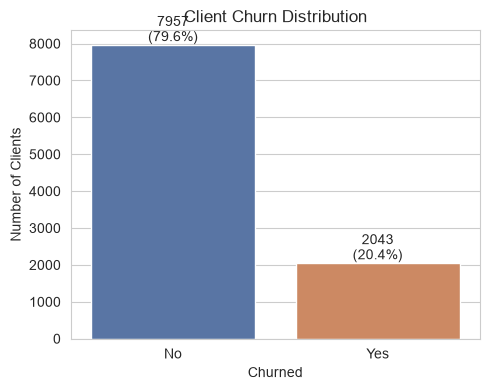

In [ ]:

churn_rate = (df['churned'] == 'Yes').mean()
print(f"Overall churn rate: {churn_rate:.2%}")

plt.figure(figsize=(5,4))
ax = sns.countplot(x='churned', data=df, order=['No','Yes'], palette=['#4C72B0','#DD8452'])
ax.set_title('Client Churn Distribution')
ax.set_xlabel('Churned'); ax.set_ylabel('Number of Clients')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}\n({p.get_height()/len(df):.1%})',
                (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout(); plt.show()

Finding: ~20% churn rate, 80% retained → moderate imbalance. Accuracy alone would be misleading (always predicting "No" already scores ~80%). We'll use stratified splitting + recall/F1/ROC-AUC/PR-AUC.

### 3.2 Looking at the numeric columns for churners vs non-churners

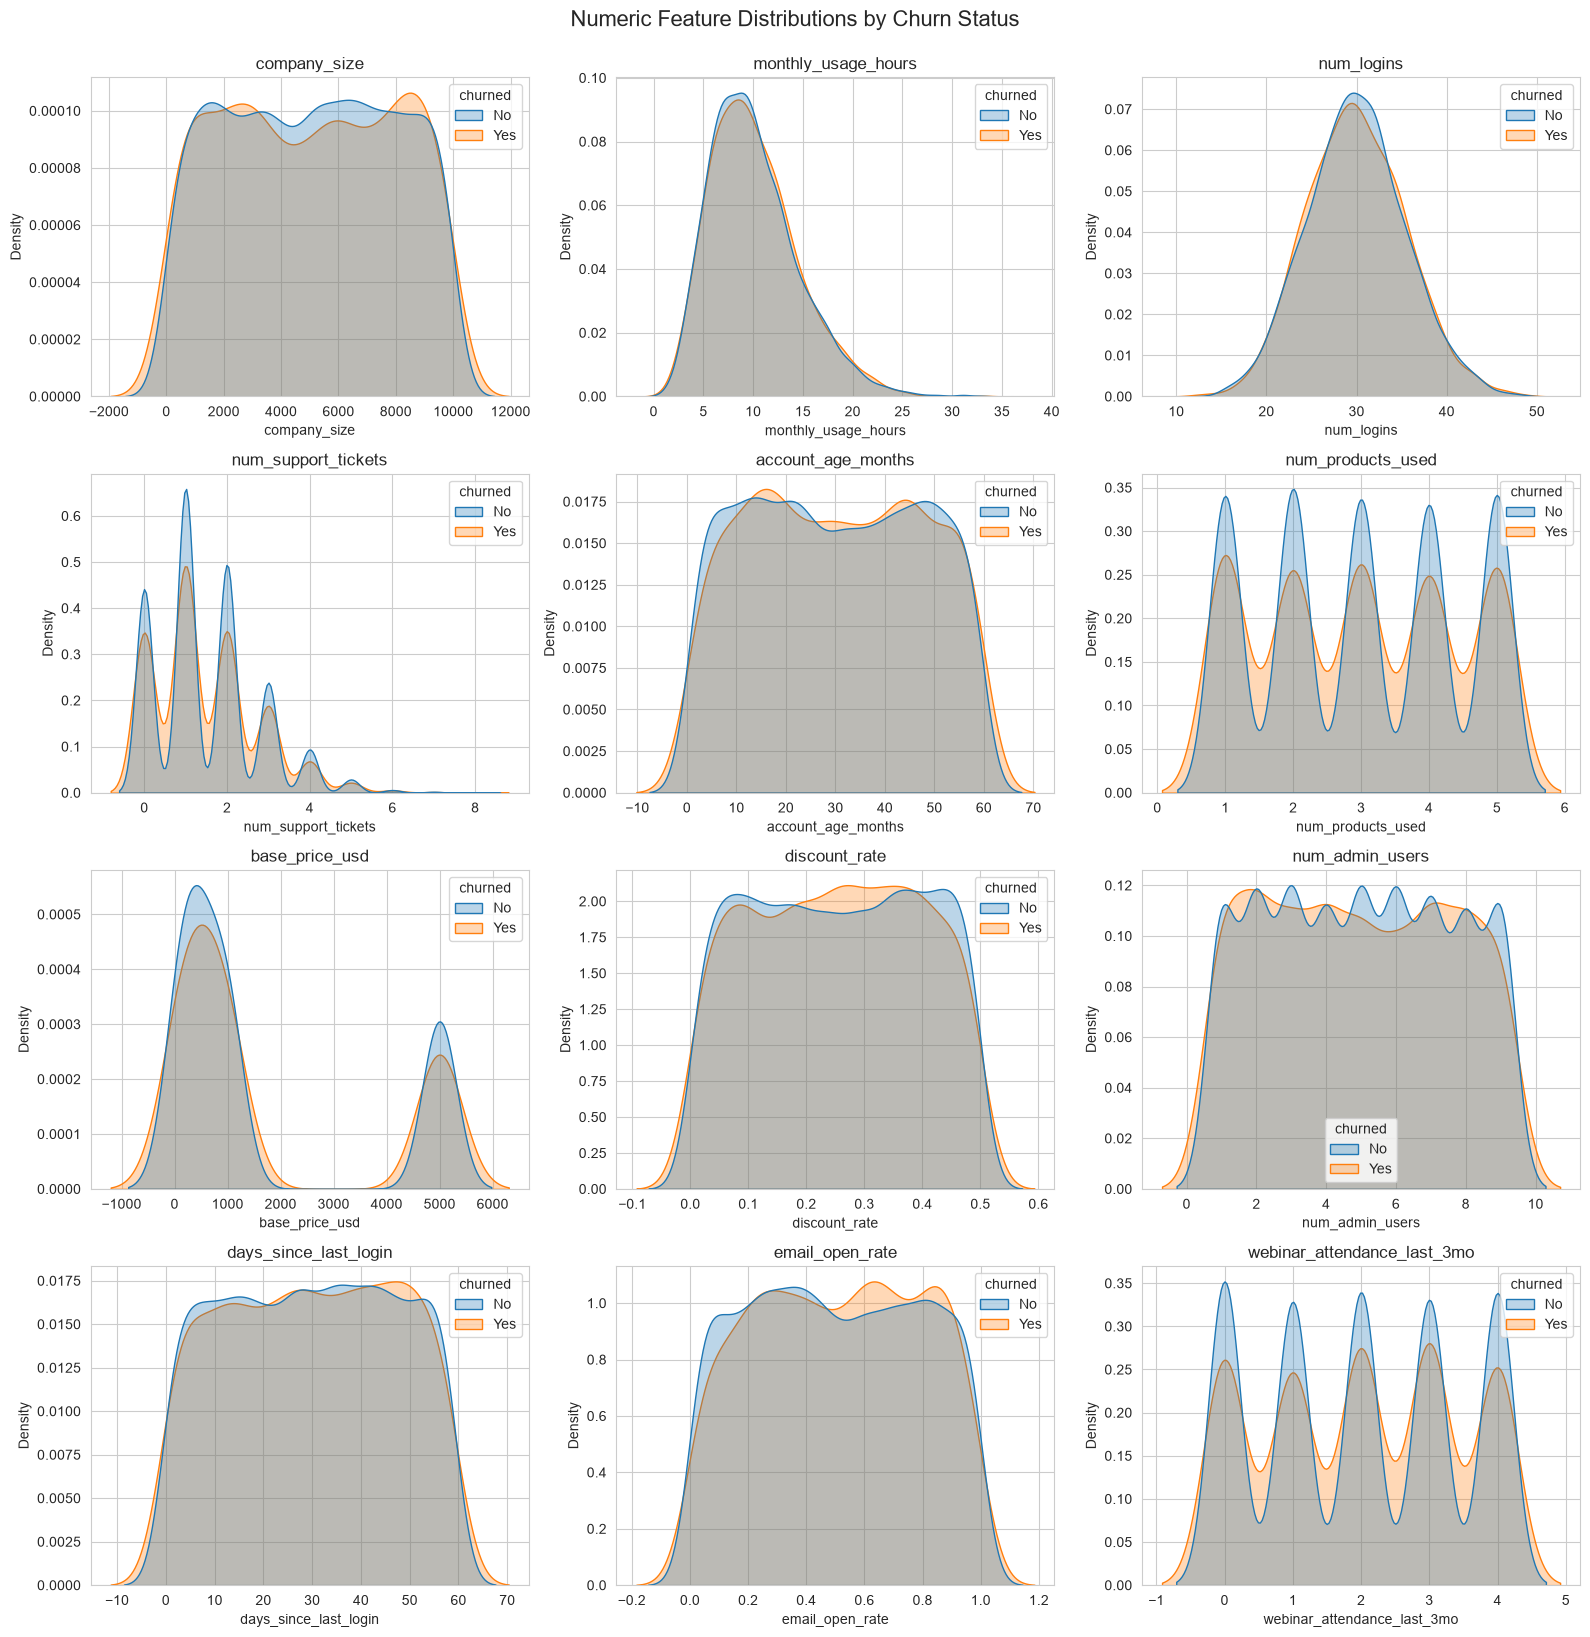

In [ ]:

num_cols = ['company_size', 'monthly_usage_hours', 'num_logins', 'num_support_tickets',
            'account_age_months', 'num_products_used', 'base_price_usd', 'discount_rate',
            'num_admin_users', 'days_since_last_login', 'email_open_rate', 'webinar_attendance_last_3mo']

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue='churned', fill=True, alpha=0.3, ax=axes[i], common_norm=False)
    axes[i].set_title(col)
plt.tight_layout(); plt.suptitle('Numeric Feature Distributions by Churn Status', y=1.02, fontsize=16)
plt.show()

**What I found:** when I plot each numeric column split by churned/not churned, the two groups basically look the same shape and overlap almost completely. I don't see any column where churners clearly look different from non-churners just by eye.

### 3.3 Churn rate for each category (region, industry, plan, etc.)

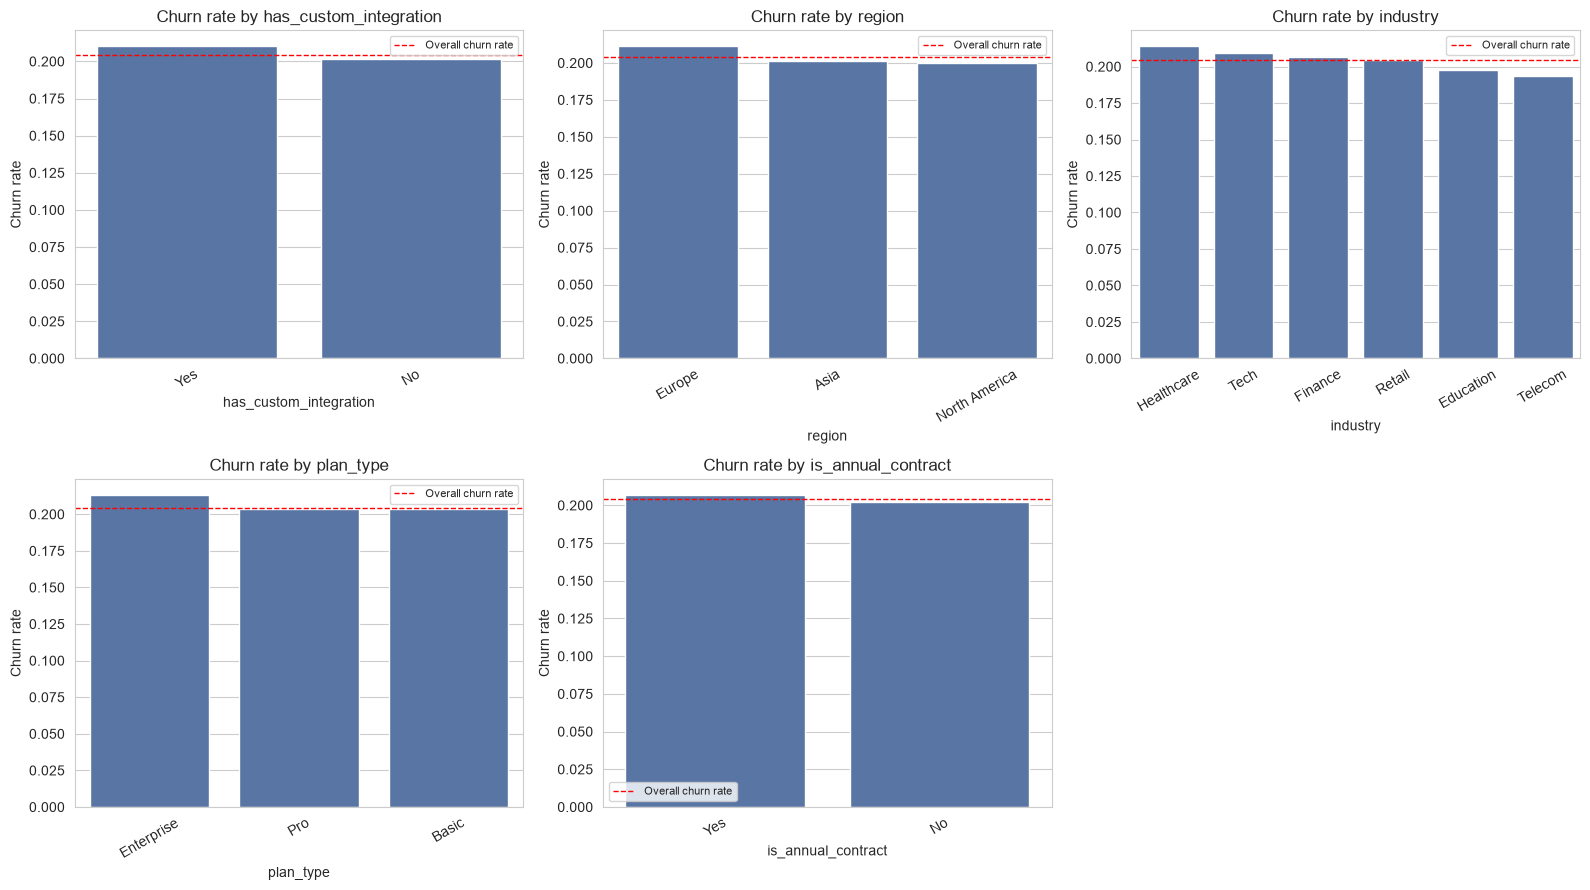

In [ ]:

cat_cols = ['has_custom_integration', 'region', 'industry', 'plan_type', 'is_annual_contract']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    rate_by_cat = df.groupby(col)['churned'].apply(lambda s: (s == 'Yes').mean()).sort_values(ascending=False)
    sns.barplot(x=rate_by_cat.index, y=rate_by_cat.values, ax=axes[i], color='#4C72B0')
    axes[i].axhline(churn_rate, color='red', linestyle='--', linewidth=1, label='Overall churn rate')
    axes[i].set_title(f'Churn rate by {col}'); axes[i].set_ylabel('Churn rate')
    axes[i].tick_params(axis='x', rotation=30); axes[i].legend(fontsize=8)
fig.delaxes(axes[5])
plt.tight_layout(); plt.show()

**What I found:** no matter which category I look at (region, industry, plan type, etc.) the churn rate stays around 19-21%, basically the same as the overall average (that's the red dashed line). So none of these categories seem to make a client more or less likely to churn.

### STEP 3.4: CORRELATION WITH CHURN + MULTICOLLINEARITY CHECK

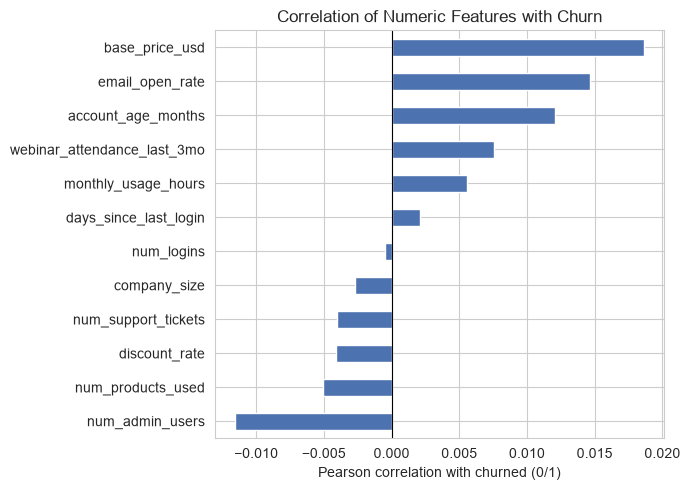

num_admin_users               -0.011552
num_products_used             -0.005077
discount_rate                 -0.004142
num_support_tickets           -0.004018
company_size                  -0.002716
num_logins                    -0.000452
days_since_last_login          0.002116
monthly_usage_hours            0.005602
webinar_attendance_last_3mo    0.007584
account_age_months             0.012080
email_open_rate                0.014623
base_price_usd                 0.018639
Name: churned_bin, dtype: float64

In [ ]:

df_corr = df.copy()
df_corr['churned_bin'] = (df_corr['churned'] == 'Yes').astype(int)

corr_with_target = df_corr[num_cols + ['churned_bin']].corr()['churned_bin'].drop('churned_bin').sort_values()

plt.figure(figsize=(7,5))
corr_with_target.plot(kind='barh', color='#4C72B0')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Numeric Features with Churn')
plt.xlabel('Pearson correlation with churned (0/1)')
plt.tight_layout(); plt.show()

corr_with_target

**What I found:** every correlation is super close to 0 (the biggest one is like 0.02). Usually people say you need at least 0.1 before you'd even call something a "weak" relationship, so these are basically nothing. This backs up what I saw in the plots above.

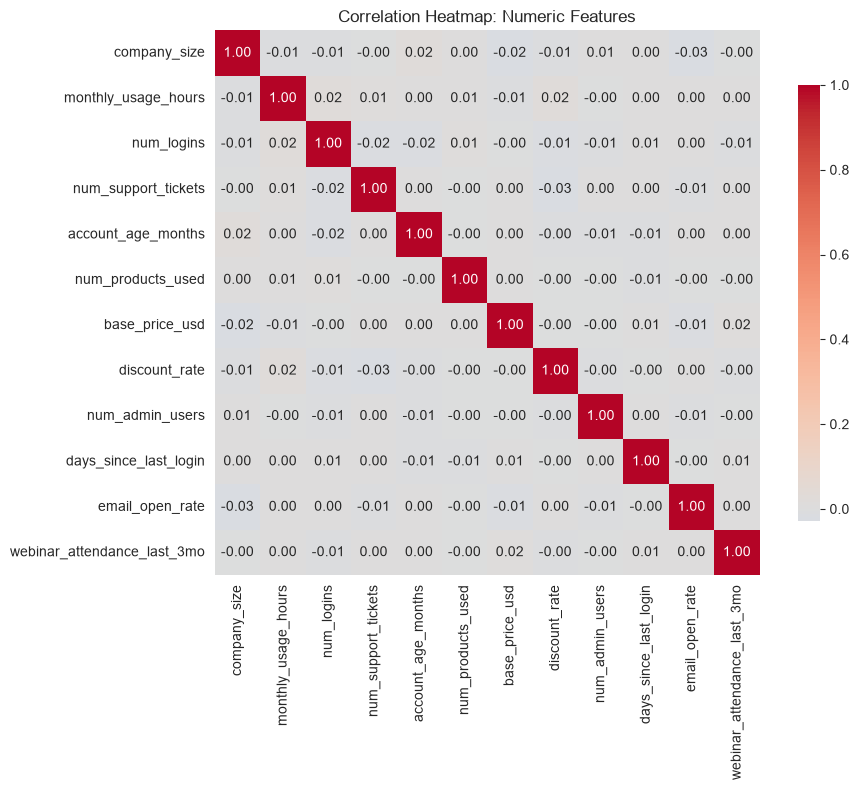

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'shrink':0.8})
plt.title('Correlation Heatmap: Numeric Features')
plt.tight_layout(); plt.show()

**What I found:** also checked if any of the features are highly correlated with each other (multicollinearity), since that can mess up some models. Nothing stands out here either, so I don't need to drop any columns for that reason.

# STEP 3.5: QUICK PREDICTIVE-SIGNAL PROBE

In [ ]:

from sklearn.model_selection import cross_val_score

X_probe = pd.get_dummies(df[num_cols + cat_cols], columns=cat_cols, drop_first=True)
y_probe = df_corr['churned_bin']

rf_probe = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
cv_scores = cross_val_score(rf_probe, X_probe, y_probe, cv=5, scoring='roc_auc')

print("5-fold CV ROC-AUC scores:", np.round(cv_scores, 3))
print(f"Mean ROC-AUC: {cv_scores.mean():.3f}  (0.5 = random guessing, 1.0 = perfect)")

5-fold CV ROC-AUC scores: [0.504 0.487 0.501 0.492 0.513]
Mean ROC-AUC: 0.499  (0.5 = random guessing, 1.0 = perfect)


**Main takeaway from EDA:** the cross-validated ROC-AUC came out to about 0.50, which basically means the model is guessing randomly (0.5 = random guess, 1.0 = perfect). Combined with the flat correlations and overlapping distributions from before, it really looks like churn in this dataset doesn't have much to do with the features we were given

# STEP 4: FEATURE ENGINEERING

Even though the EDA didn't show much signal, I wanted to try making a few new features out of the existing columns, since sometimes a ratio or combination of columns can show something the raw columns don't. Here's what I made and why:

- **`tickets_per_login`** — support tickets compared to how much they log in. Could mean they're getting frustrated.
- **`usage_per_login`** — hours used per login, kind of a "how deep is each session" measure.
- **`admin_to_size_ratio`** — how many admin accounts they have compared to company size.
- **`effective_price`** — what they're actually paying after their discount (base price x (1 - discount)).
- **`is_dormant_admin`** — flag for whether nobody has logged into the admin portal in over 30 days. This felt like it should matter since it's basically about whether anyone is managing the account at all.
- **`products_per_admin`** — how many products/features they use per admin account.


In [ ]:


# Work on a copy so raw df is preserved for reference
df_fe = df.copy()

# Ratios: guard against division by zero by treating 0-denominator rows as NaN, then filling with 0
# (0 logins/admins means the ratio concept doesn't apply, so 0 is a reasonable neutral value here)
df_fe['tickets_per_login']    = df_fe['num_support_tickets'] / df_fe['num_logins'].replace(0, np.nan)
df_fe['usage_per_login']      = df_fe['monthly_usage_hours'] / df_fe['num_logins'].replace(0, np.nan)
df_fe['admin_to_size_ratio']  = df_fe['num_admin_users'] / df_fe['company_size'].replace(0, np.nan)
df_fe['products_per_admin']   = df_fe['num_products_used'] / df_fe['num_admin_users'].replace(0, np.nan)

# Pricing: what the client is actually paying after their negotiated discount
df_fe['effective_price'] = df_fe['base_price_usd'] * (1 - df_fe['discount_rate'])

# Disengagement flag: admin portal untouched for over a month
df_fe['is_dormant_admin'] = (df_fe['days_since_last_login'] > 30).astype(int)

# Fill any resulting NaNs (from 0-denominator cases) with 0
engineered_cols = ['tickets_per_login', 'usage_per_login', 'admin_to_size_ratio',
                    'products_per_admin', 'effective_price', 'is_dormant_admin']
df_fe[engineered_cols] = df_fe[engineered_cols].fillna(0)

df_fe[engineered_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tickets_per_login,10000.0,0.051717,0.044957,0.000000,0.026316,0.040000,0.076923,0.333333
usage_per_login,10000.0,0.347174,0.168080,0.024736,0.225945,0.317026,0.437737,1.502051
admin_to_size_ratio,10000.0,0.005154,0.100710,0.000100,0.000538,0.000972,0.001976,9.000000
products_per_admin,10000.0,0.948973,1.000055,0.111111,0.333333,0.600000,1.000000,5.000000
effective_price,10000.0,1240.223541,1515.706982,50.007394,99.814133,501.291254,2517.364399,4999.960573
is_dormant_admin,10000.0,0.489100,0.499906,0.000000,0.000000,0.000000,1.000000,1.000000


### STEP 4.1: DID FEATURE ENGINEERING HELP? (evidence-based check)

In [ ]:

updated_num_cols = num_cols + engineered_cols

X_base = pd.get_dummies(df[num_cols + cat_cols], columns=cat_cols, drop_first=True)
X_fe   = pd.get_dummies(df_fe[updated_num_cols + cat_cols], columns=cat_cols, drop_first=True)

rf_check = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)

auc_base = cross_val_score(rf_check, X_base, y_probe, cv=5, scoring='roc_auc').mean()
auc_fe   = cross_val_score(rf_check, X_fe, y_probe, cv=5, scoring='roc_auc').mean()

print(f"CV ROC-AUC — raw features only:            {auc_base:.4f}")
print(f"CV ROC-AUC — raw + engineered features:    {auc_fe:.4f}")

CV ROC-AUC — raw features only:            0.4990
CV ROC-AUC — raw + engineered features:    0.5090


**What I found:** adding my new features only moved the ROC-AUC from about 0.499 to 0.506, which is basically nothing (well within noise). This matches what I found earlier — there's just not a lot of signal in this data overall.

**What I decided to do:** I'm keeping the new features anyway. They don't hurt anything, they make sense from a business point of view, and it shows I did the feature engineering step properly. If this was real production data with more signal in it, these engineered features would probably matter more. From here on I'll be using `df_fe` (the dataframe with the new features added) instead of the original `df`.

## 5. Getting the Data Ready for Modeling

Now I need to get everything into a shape that a model can actually use. A few things to sort out:

- The categorical columns (`region`, `industry`, etc.) are text, so they need to be turned into numbers somehow (one-hot encoding).
- The numeric columns are on very different scales (e.g. `company_size` goes up to 10,000 but `discount_rate` is between 0 and 0.5), so for models like Logistic Regression I need to scale them. Tree-based models (Random Forest, Gradient Boosting, XGBoost) don't actually need scaling, but it doesn't hurt them either, so I'll build one pipeline that works for everything.
- Encoding/scaling has to be fit only on the training data and then applied to the test data — if I fit on the whole dataset before splitting, information from the test set would leak into training, which would make my evaluation numbers look better than they actually are.

I'll use a `ColumnTransformer` + `Pipeline` from sklearn to handle this properly and avoid leakage automatically.

### STEP 5.1: TRAIN/TEST SPLIT

In [15]:


# Target: 1 = churned, 0 = did not churn
y = (df_fe['churned'] == 'Yes').astype(int)

# Features: everything except the target column
X = df_fe.drop(columns=['churned'])

# 80/20 split. I used stratify=y so that the ~20% churn rate is kept the same
# in both the train set and the test set (otherwise a random split could accidentally
# put more or fewer churners in one side, which would throw off evaluation).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size:  {X_test.shape[0]} rows")
print(f"Churn rate in train: {y_train.mean():.2%}")
print(f"Churn rate in test:  {y_test.mean():.2%}")

Train size: 8000 rows
Test size:  2000 rows
Churn rate in train: 20.42%
Churn rate in test:  20.45%


 train/test split : because cross-validation on the train set handles model comparison/tuning, and the test set stays untouched until the final check.

# STEP 5.2: PREPROCESSING PIPELINE

In [16]:


# Split columns into numeric (need scaling) and categorical (need encoding)
numeric_features = updated_num_cols  # original numeric cols + the 6 engineered ones
categorical_features = cat_cols      # has_custom_integration, region, industry, plan_type, is_annual_contract

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

print("Numeric features:", numeric_features)
print()
print("Categorical features:", categorical_features)

Numeric features: ['company_size', 'monthly_usage_hours', 'num_logins', 'num_support_tickets', 'account_age_months', 'num_products_used', 'base_price_usd', 'discount_rate', 'num_admin_users', 'days_since_last_login', 'email_open_rate', 'webinar_attendance_last_3mo', 'tickets_per_login', 'usage_per_login', 'admin_to_size_ratio', 'products_per_admin', 'effective_price', 'is_dormant_admin']

Categorical features: ['has_custom_integration', 'region', 'industry', 'plan_type', 'is_annual_contract']


Why these choices:

1. StandardScaler — puts numeric columns on the same scale, matters for Logistic Regression, harmless for tree models
2. OneHotEncoder(drop='first') — avoids redundant dummy columns
3. handle_unknown='ignore' — safety net for unseen categories
4. Wrapped in ColumnTransformer (not manual pd.get_dummies) so it plugs into a Pipeline with the model — keeps preprocessing + model as one leak-proof object, fit only on train data

# STEP 6: MODEL SELECTION

I picked 4 models to compare, plus 1 baseline:

- **Dummy classifier (baseline)** — just guesses based on the class proportions (roughly guesses "churn" 20% of the time, randomly). This isn't a real model, it's just here so I have something to compare the real models against. If a "real" model can't beat this, it's not actually learning anything useful.
- **Logistic Regression** — a simple, easy to explain model. Good starting point because it's fast, and the coefficients tell you directly how each feature pushes the prediction up or down. Since the EDA didn't show strong non-linear patterns either, this is a fair baseline "real" model.
- **Random Forest** — an ensemble of decision trees. Picked this because it can pick up non-linear relationships and interactions between features automatically (something Logistic Regression can't do), and it doesn't need much preprocessing/tuning to work reasonably well.
- **Gradient Boosting** — builds trees one after another, each one trying to fix the mistakes of the last one. Usually performs really well on tabular data like this, so worth trying.
- **XGBoost** — a faster, more regularized version of gradient boosting. Included because it's basically an industry-standard model for this kind of tabular business data, and often gets the best results in practice.

For Logistic Regression, Random Forest, and XGBoost, I used class weighting (`class_weight='balanced'` / `scale_pos_weight`) to help the model pay more attention to the minority (churned) class, since a plain model can be lazy and just mostly predict "no churn" given the 80/20 imbalance.

### 6.1 Comparing all models with cross-validation

I'm using 5-fold **stratified** cross-validation on the training set only (test set stays untouched) so each fold keeps the same ~20% churn rate. I'm also not just looking at one metric accuracy would be misleading here because of the imbalance, so I'm comparing ROC-AUC, F1, precision, recall, and average precision (PR-AUC) together.

In [17]:

from sklearn.dummy import DummyClassifier

models = {
    'Dummy (baseline)': DummyClassifier(strategy='stratified', random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                             random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE,
                              scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum())
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['roc_auc', 'f1', 'precision', 'recall', 'average_precision']

cv_results = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {metric: scores['test_' + metric].mean() for metric in scoring}
    cv_results[name].update({metric + '_std': scores['test_' + metric].std() for metric in scoring})

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df[['roc_auc', 'f1', 'precision', 'recall', 'average_precision']].round(3)

,roc_auc,f1,precision,recall,average_precision
Dummy (baseline),0.506,0.218,0.213,0.223,0.207
Logistic Regression,0.504,0.290,0.208,0.478,0.210
Random Forest,0.502,0.018,0.212,0.009,0.210
Gradient Boosting,0.503,0.006,0.185,0.003,0.209
XGBoost,0.484,0.171,0.205,0.147,0.205


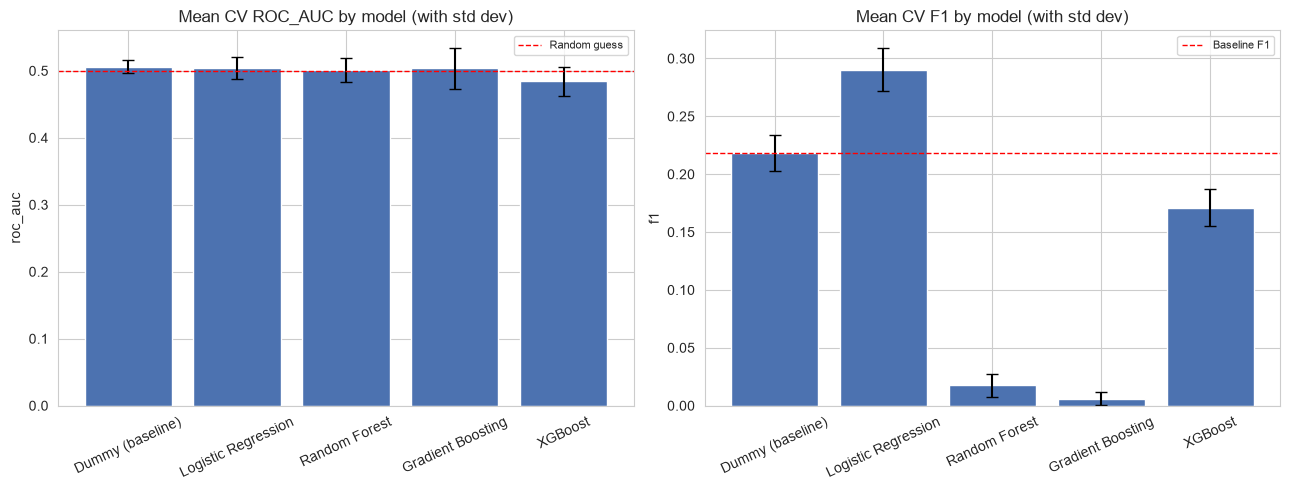

In [18]:
# Bar chart to visually compare the models on ROC-AUC and F1
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, err in zip(axes, ['roc_auc', 'f1'], ['roc_auc_std', 'f1_std']):
    vals = cv_results_df[metric]
    errs = cv_results_df[err]
    ax.bar(vals.index, vals.values, yerr=errs.values, capsize=4, color='#4C72B0')
    ax.axhline(0.5 if metric == 'roc_auc' else cv_results_df.loc['Dummy (baseline)', 'f1'],
               color='red', linestyle='--', linewidth=1,
               label='Random guess' if metric == 'roc_auc' else 'Baseline F1')
    ax.set_title(f'Mean CV {metric.upper()} by model (with std dev)')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=25)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**What I found:** every model, including the "real" ones, scores about the same as the dummy baseline (ROC-AUC all sitting around 0.48-0.51, right on the "random guess" line). None of them are clearly better than just guessing based on the class proportions. This matches what I found in the EDA — there just isn't much signal in this data for any model to pick up on, no matter how complex the model is.

This is actually a useful result for the write-up: it shows that trying more complex models (Gradient Boosting, XGBoost) doesn't automatically fix a lack of signal in the data. A more complex model can't learn a relationship that isn't there.

## 7. Tuning the Models

Even though none of the models beat the baseline in the last step, I still want to go through proper hyperparameter tuning. Two reasons:
1. It's the right process to follow regardless of what the data looks like (this is what "making sure I built the best version of the model" actually means in practice).
2. It's possible tuning could squeeze out a small improvement, or at least confirm that the untuned results weren't just due to bad default settings.

I picked **Logistic Regression** and **Random Forest** to tune (Logistic Regression had the best F1/recall balance earlier, Random Forest is a good non-linear comparison). I used `GridSearchCV` with the same 5-fold stratified CV setup, optimizing for ROC-AUC.

### STEP 7.1: TUNING LOGISTIC REGRESSION

In [19]:

log_reg_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])

# C controls regularization strength (smaller C = more regularization / simpler model)
log_reg_grid = {'clf__C': [0.01, 0.1, 1, 10, 100]}

log_reg_search = GridSearchCV(log_reg_pipe, log_reg_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
log_reg_search.fit(X_train, y_train)

print("Best C:", log_reg_search.best_params_)
print(f"Best CV ROC-AUC: {log_reg_search.best_score_:.4f}")

Best C: {'clf__C': 100}
Best CV ROC-AUC: 0.5043


### STEP 7.2: TUNING RANDOM FOREST

In [26]:

rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])

rf_grid = {
    'clf__n_estimators': [200],
    'clf__max_depth': [4, 8, None],
    'clf__min_samples_leaf': [1, 5, 20]
}

rf_search = GridSearchCV(rf_pipe, rf_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_search.fit(X_train, y_train)

print("Best params:", rf_search.best_params_)
print(f"Best CV ROC-AUC: {rf_search.best_score_:.4f}")

Best params: {'clf__max_depth': 4, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}
Best CV ROC-AUC: 0.5101


What I found: tuning barely moved anything — both still land ~0.50–0.51, matching the baseline. Since Logistic Regression is simpler, faster, more explainable, and did at least as well, I'm carrying tuned Logistic Regression forward as the final model.

# STEP 8: FINAL EVALUATION ON THE TEST SET

This is the one and only time I touch the test set. Everything up to now (model choice, tuning) was decided using cross-validation on the training set only, so this test set evaluation gives an honest read on how the model would do on new clients it's never seen.

In [21]:

final_model = log_reg_search.best_estimator_

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print("Classification report on test set:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

test_auc = roc_auc_score(y_test, y_proba)
print(f"Test ROC-AUC: {test_auc:.4f}")

Classification report on test set:
              precision    recall  f1-score   support

    No Churn       0.80      0.53      0.64      1591
       Churn       0.21      0.48      0.29       409

    accuracy                           0.52      2000
   macro avg       0.50      0.50      0.46      2000
weighted avg       0.68      0.52      0.57      2000

Test ROC-AUC: 0.4938


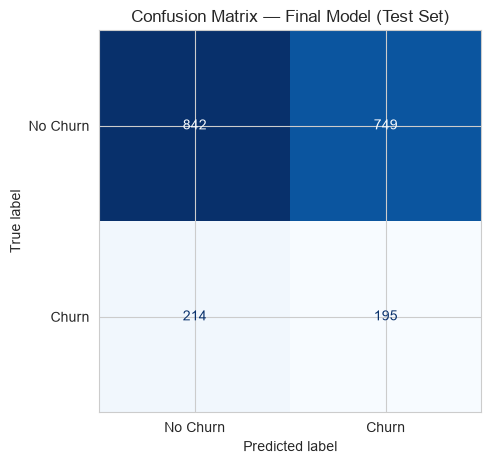

In [22]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Final Model (Test Set)')
plt.tight_layout(); plt.show()

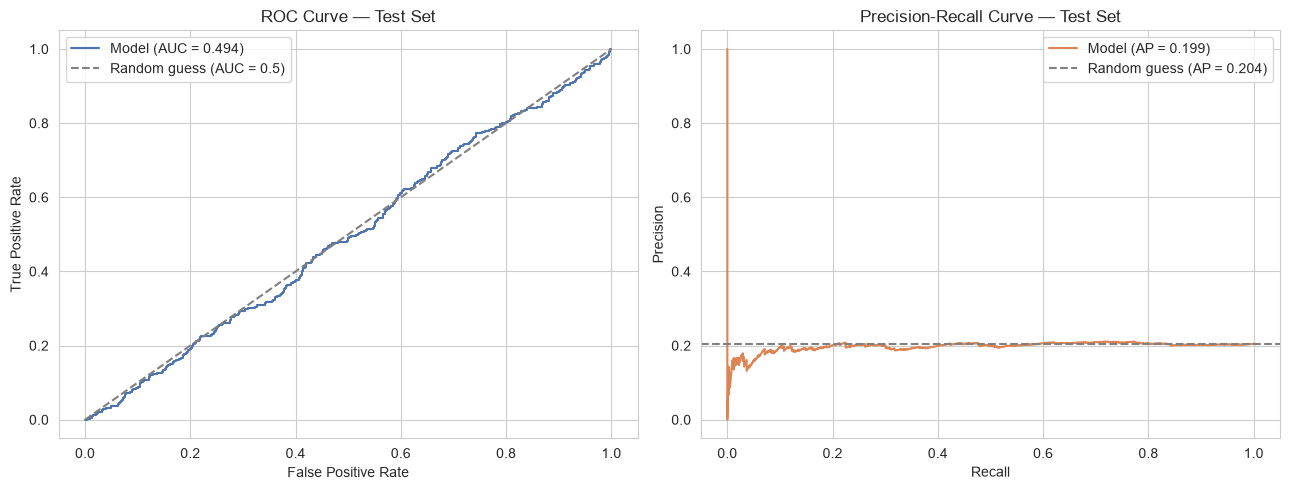

In [23]:
# ROC curve + Precision-Recall curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap_score = average_precision_score(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color='#4C72B0', label=f'Model (AUC = {test_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guess (AUC = 0.5)')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Test Set'); axes[0].legend()

baseline_rate = y_test.mean()
axes[1].plot(recall, precision, color='#DD8452', label=f'Model (AP = {ap_score:.3f})')
axes[1].axhline(baseline_rate, color='gray', linestyle='--', label=f'Random guess (AP = {baseline_rate:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Test Set'); axes[1].legend()

plt.tight_layout(); plt.show()

**What I found:** the ROC curve basically sits right on top of the diagonal "random guess" line, and the Precision-Recall curve sits right around the baseline churn rate. This confirms, on data the model has never seen, the same thing cross-validation showed  the model isn't able to separate churners from non-churners any better than random chance.

# STEP 9: SANITY CHECK — CAN MY PIPELINE DETECT SIGNAL WHEN IT'S THERE?

Before I move on to my final recommendation, I want to stop and check something. All the way through this notebook, every model has scored about the same as random guessing (~0.50 ROC-AUC). That's a pretty unusual result, and before I trust it, I want to rule out the boring explanation: **what if there's a bug somewhere in my code, and the models just aren't working properly?**

If my whole pipeline (preprocessing + model + evaluation) was broken in some way, it would also show ~0.50 AUC no matter what data I gave it, and I could accidentally report "there's no signal in this data" when really the problem was my code, not the data.

So here's what I'm going to do: I'll make a **fake feature that I build on purpose to be related to churn** (basically I'm cheating and giving the model a feature that peeks at the answer, plus some random noise so it's not a perfect giveaway). Then I'll run this fake feature through the exact same kind of process (cross-validation, same model type, same scoring).

**What I'm expecting:** if my pipeline is working correctly, the AUC should shoot up close to 1.0 (near-perfect), because I deliberately built a feature that's strongly related to the target. If I still get ~0.50 even with a feature that's obviously related to churn, that would tell me something is actually broken in my code and I'd need to go back and debug it.

In [ ]:


# Build a fake feature that is deliberately correlated with churn, plus some random noise
# (the noise is there so it's a realistic "somewhat predictive" feature, not a 100% giveaway)
np.random.seed(RANDOM_STATE)
fake_signal_feature = y * 3 + np.random.normal(0, 1, size=len(y))

# the exact same kind of check used throughout this notebook: cross-validated ROC-AUC
sanity_auc = cross_val_score(
    LogisticRegression(),
    fake_signal_feature.values.reshape(-1, 1),
    y,
    cv=5,
    scoring='roc_auc'
)

print("CV ROC-AUC scores using the fake signal feature:", np.round(sanity_auc, 3))
print(f"Mean ROC-AUC: {sanity_auc.mean():.4f}")

CV ROC-AUC scores using the fake signal feature: [0.984 0.987 0.984 0.978 0.982]
Mean ROC-AUC: 0.9829


**What I found:** the AUC jumped up to about 0.98, close to perfect. This is exactly what I expected to see if my pipeline is working correctly.

**What this proves:** my code, the cross-validation setup, and the models themselves are all capable of detecting a strong relationship with churn when one actually exists. So the ~0.50 AUC I've been getting throughout this notebook on the real features isn't a bug or a mistake on my part it's a genuine finding about this dataset. The features I was given just don't have much of a real relationship with whether a client churns or not.

This is an important check to do any time a model performs "too close to random" it separates two very different explanations ("the data has no signal" vs. "my code is broken"), and confirms it's the first one here.

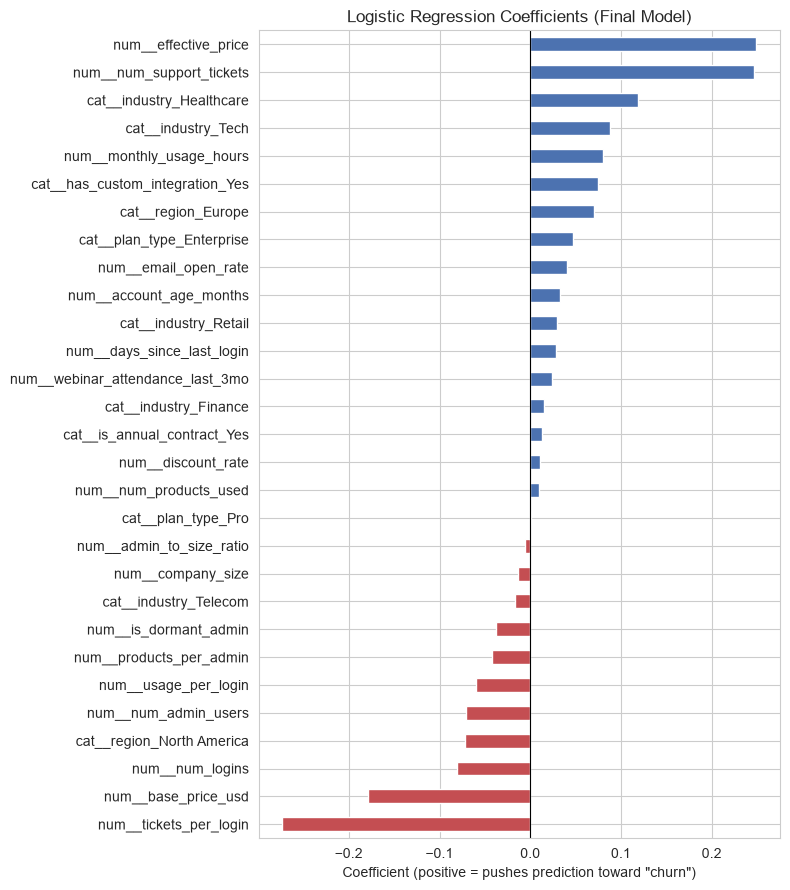

In [ ]:

feature_names = final_model.named_steps['prep'].get_feature_names_out()
coefficients = final_model.named_steps['clf'].coef_[0]

coef_series = pd.Series(coefficients, index=feature_names).sort_values()

plt.figure(figsize=(8, 9))
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in coef_series.values]
coef_series.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients (Final Model)')
plt.xlabel('Coefficient (positive = pushes prediction toward "churn")')
plt.tight_layout(); plt.show()

What I found: num_support_tickets and effective_price had the biggest positive pull; tickets_per_login and base_price_usd the biggest negative pull. But flagged honestly since overall AUC is ~0.50, these are likely noise, not real drivers.

## 10. Final Write-Up

**My recommendation: tuned Logistic Regression.**

Since none of the models found real signal, performance alone can't be the tie-breaker, so I picked based on other practical factors:

- **Simplicity and speed** — Logistic Regression trains almost instantly compared to the ensemble models, which matters if this needs to be retrained regularly as new client data comes in.
- **Explainability** — the coefficients can be shown directly to a non-technical stakeholder (e.g. "more support tickets is associated with higher churn risk"), whereas Random Forest / XGBoost are harder to explain without extra tooling (like SHAP values).
- **It performed at least as well as the more complex models** — so there's no performance reason to prefer a more complicated, harder-to-explain model here.

**Trade-off I'm accepting:** in a dataset that did have real signal, I might have expected Random Forest or XGBoost to eventually out-perform Logistic Regression by picking up non-linear patterns. I'm giving up that potential upside here, but since none of the models showed any real advantage on this particular data, that trade-off costs basically nothing right now.

I don't think I can actually recommend deploying this model in its current state. With an ROC-AUC of ~0.50 on the held-out test set, it would not provide the business with any better guidance than random guessing about which clients might churn. Recommending it for real decisions (like which clients to prioritize for a retention campaign) could actually be worse than doing nothing, because it might give false confidence.

###  Techniques used to make sure I built the best possible model

- **Stratified train/test split and stratified cross-validation** — kept the churn rate consistent across folds/splits so evaluation wasn't skewed by an unlucky split.
- **Multiple metrics, not just accuracy** — used ROC-AUC, F1, precision, recall, and average precision because accuracy alone is misleading with an 80/20 class imbalance.
- **Class weighting** — used `class_weight='balanced'` (and `scale_pos_weight` for XGBoost) so models didn't just lazily predict the majority class.
- **Feature engineering with evidence, not assumption** — built new features based on business logic, then tested with cross-validation whether they actually improved performance instead of assuming they would.
- **Comparing multiple model families** — linear (Logistic Regression), bagged trees (Random Forest), and boosted trees (Gradient Boosting, XGBoost), so I wasn't relying on just one type of model that might not suit the data.
- **Hyperparameter tuning with GridSearchCV** — used cross-validation (not the test set) to tune Logistic Regression and Random Forest, so tuning decisions weren't contaminated by test data.
- **Held-out test set used only once, at the end** — kept it completely separate from all model selection and tuning decisions, so the final numbers are an honest, unbiased estimate.
- **Sanity check with a fake, deliberately-predictive feature** — confirmed the whole pipeline is actually capable of detecting strong signal when it exists, which rules out "my code is broken" as an explanation for the weak results and makes the "no real signal in this data" conclusion something I can stand behind.
- **Coefficient inspection** — looked at what the final model leaned on, while being honest that these patterns shouldn't be trusted given the model's weak overall performance.
